### Data Loading & Preprocessing

In [16]:
import pandas as pd

csv_roof = '../files2/final'
df_acc = pd.read_csv(f"{csv_roof}/seoul_accidents.csv")
df_light = pd.read_csv(f"{csv_roof}/seoul_traffic_lights.csv")

In [17]:
print(df_acc.shape)
df_acc.head(2)

(3619, 12)


,year,month,day,hour,day_night,day_of_week,city,district,accident_type,lon,lat,datetime
0,2012,1,13,16,주간,화,서울,강서구,차량단독,126.821995,37.544155,2012-01-13 16:00:00
1,2012,7,9,10,주간,월,서울,서초구,차대차,127.051443,37.451040,2012-07-09 10:00:00


In [18]:
print(df_light.shape)
df_light.head(2)

(24138, 5)


,district,light_type,lat,lon,address
0,강남구,보행등,37.498560,127.044475,강남구 역삼동 710 대
1,강남구,보행등,37.509105,127.033164,강남구 논현동 219-12 대


---

#### 1️⃣ 좌표계 통일 & KD-Tree 색인

In [20]:
# KD-Tree 생성
from scipy.spatial import cKDTree
tree = cKDTree(df_light[["lat","lon"]].values)

#### 2️⃣ 사고→최근접 보행등 거리 분포

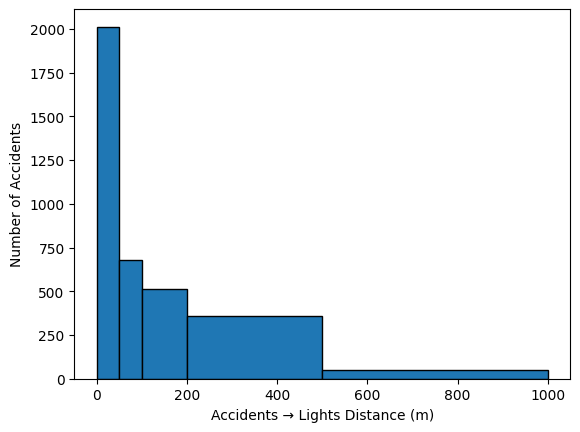

In [22]:
# 거리 계산 함수:
from geopy.distance import geodesic
import numpy as np

dists = []
for lat, lon in zip(df_acc.lat, df_acc.lon):
    _, idx = tree.query((lat, lon))
    lt = df_light.iloc[idx]
    dists.append(geodesic((lat,lon),(lt.lat,lt.lon)).meters)
dists = np.array(dists)

#히스토그램 시각화:
import matplotlib.pyplot as plt

bins = [0,50,100,200,500,1000]
plt.hist(dists, bins=bins, edgecolor="k")
plt.xlabel("Accidents → Lights Distance (m)")
plt.ylabel("Number of Accidents")
plt.show()

---
### 3. 행정구역별 집계 & 상관분석

구별 상관계수: 0.80


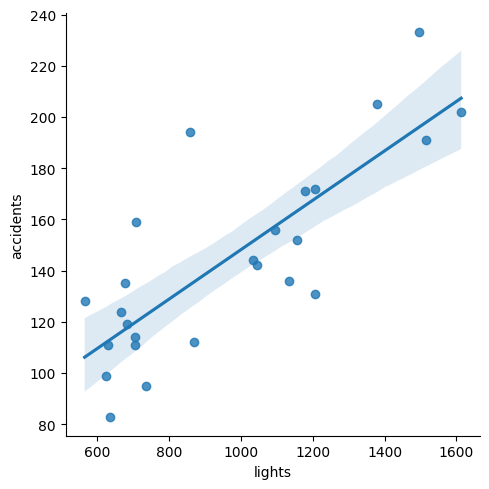

In [25]:
# 구별 집계
acc_cnt  = df_acc.groupby("district").size().rename("accidents")
light_cnt = df_light.groupby("district").size().rename("lights")
df_stat   = pd.concat([acc_cnt, light_cnt], axis=1).fillna(0)

# 피어슨 상관계수
corr = df_stat["accidents"].corr(df_stat["lights"])
print(f"구별 상관계수: {corr:.2f}")

# 산점도 + 회귀선
import seaborn as sns
sns.lmplot(data=df_stat.reset_index(), x="lights", y="accidents")


In [29]:
gs = 0.005
df_acc["gx"] = (df_acc.lat//gs)*gs; df_acc["gy"] = (df_acc.lon//gs)*gs
df_light["gx"] = (df_light.lat//gs)*gs; df_light["gy"] = (df_light.lon//gs)*gs

a = df_acc.groupby(["gx","gy"]).size().rename("A")
l = df_light.groupby(["gx","gy"]).size().rename("L")
df_grid = a.to_frame().join(l, how="outer").fillna(0)
print("Grid 상관계수:", df_grid["A"].corr(df_grid["L"]))

df_grid["score"] = df_grid.A - df_grid.L
hotspots = df_grid.nlargest(5, "score").reset_index()
hotspots

Grid 상관계수: 0.26203156719956916


,gx,gy,A,L,score
0,37.590,126.800,7.0,0.0,7.0
1,37.520,126.880,10.0,4.0,6.0
2,37.540,126.985,5.0,0.0,5.0
3,37.550,126.880,5.0,0.0,5.0
4,37.565,126.945,5.0,0.0,5.0


<Axes: xlabel='day_of_week'>

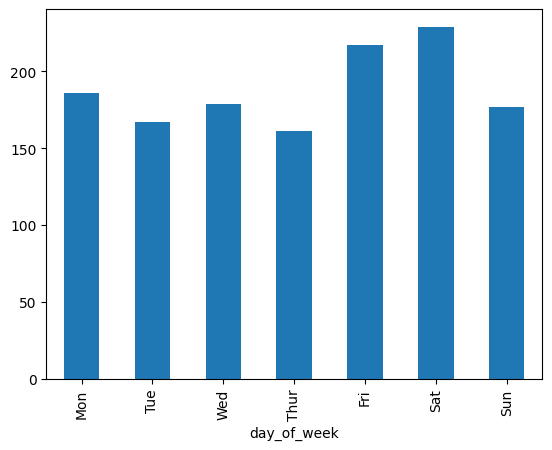

In [31]:
df_acc["hour"].value_counts().sort_index().plot(kind="bar")
df_acc["day_of_week"].value_counts().reindex(
    ["Mon","Tue","Wed","Thur","Fri","Sat","Sun"]
).plot(kind="bar")


<Axes: ylabel='accident_type'>

/home/nute11a/anaconda3/envs/PBL/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from current font.
  func(*args, **kwargs)
/home/nute11a/anaconda3/envs/PBL/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  func(*args, **kwargs)
/home/nute11a/anaconda3/envs/PBL/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.
  func(*args, **kwargs)
/home/nute11a/anaconda3/envs/PBL/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from current font.
  func(*args, **kwargs)
/home/nute11a/anaconda3/envs/PBL/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from current font.
  func(*args, **kwargs)
/home/nute11a/anaconda3/envs/PBL/lib/python3.8/sit

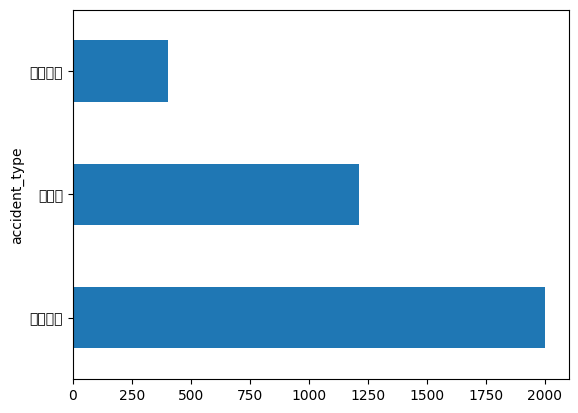

In [33]:
df_acc["accident_type"].value_counts().plot(kind="barh")

In [38]:
import folium
from folium.plugins import HeatMap, MarkerCluster
from streamlit_folium import st_folium

m = folium.Map([37.56,126.97], zoom_start=11, tiles="CartoDB positron")

# 사고 히트맵
heat = [[r.lat, r.lon] for _,r in df_acc.iterrows()]
HeatMap(heat, radius=10, blur=15).add_to(m)

# 보행등 클러스터
mc = MarkerCluster(name="보행등").add_to(m)
for _, r in df_light.iterrows():
    folium.CircleMarker(
        [r.lat, r.lon], radius=3,
        color="blue", fill=True
    ).add_to(mc)

folium.LayerControl().add_to(m)
st_folium(m, width=800, height=600)


2025-05-22 01:14:40.784 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-22 01:14:49.382 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-22 01:14:49.383 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-22 01:14:49.384 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-22 01:14:49.475 
  command:

    streamlit run /home/nute11a/anaconda3/envs/PBL/lib/python3.8/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-05-22 01:14:49.486 Thread 'MainThread': missing ScriptRunContext! This warning ca

{'last_clicked': None,
 'last_object_clicked': None,
 'last_object_clicked_tooltip': None,
 'last_object_clicked_popup': None,
 'all_drawings': None,
 'last_active_drawing': None,
 'bounds': {'_southWest': {'lat': 37.42876988, 'lng': 126.7690357},
  '_northEast': {'lat': 37.69279296, 'lng': 127.18426531}},
 'zoom': 11,
 'last_circle_radius': None,
 'last_circle_polygon': None}

In [39]:
df_acc = df_acc[df_acc['district'] == '강남구']
df_light = df_light[df_light['district'] == '강남구']